# E-commerce Customer Analytics and Sales Forecasting
## Notebook 04 — Customer Segmentation

### Overview

Customer segmentation is a core task in marketing analytics.

By grouping customers with similar behavioral patterns, businesses can design targeted strategies that improve engagement, retention, and revenue.

In this notebook we apply unsupervised machine learning techniques to identify meaningful customer segments based on behavioral and transactional features.

---

### Objectives

The objectives of this notebook are:

1. Identify natural groups of customers based on behavioral features
2. Compare multiple clustering algorithms
3. Visualize cluster structure
4. Profile clusters to understand customer characteristics
5. Translate clusters into actionable business segments

---

### Algorithms Used

We experiment with several clustering methods:

KMeans

A centroid-based algorithm widely used in customer segmentation.

Hierarchical Clustering

Builds clusters in a tree structure that allows hierarchical interpretation.

DBSCAN

A density-based clustering method that can detect outliers and irregular cluster shapes.

---

### Dataset

This notebook uses the **customer feature dataset** generated during the feature engineering stage.

In [1]:
"""
Environment Setup
"""

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/processed"
FIG_PATH = "../figures/customer_segmentation"

os.makedirs(FIG_PATH, exist_ok=True)

print("Environment initialized.")

Environment initialized.


In [2]:
"""
Load Customer Feature Dataset
"""

customer_features = pd.read_csv(
    f"{DATA_PATH}/model_features_customers.csv"
)

print("Dataset shape:", customer_features.shape)

customer_features.head()

Dataset shape: (10000, 28)


,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase,customer_tenure_days_x,engagement_index,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order,customer_tenure_days_y,purchase_rate
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0,730,4.461865,7.0,47.0,4547.73,2.0,3.0,3.0,233.0,At Risk,96.760213,730.0,0.064295
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0,728,5.731441,10.0,68.0,5440.13,2.0,4.0,3.0,243.0,At Risk,80.001912,728.0,0.093278
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0,728,5.564010,4.0,40.0,3978.12,3.0,2.0,2.0,322.0,At Risk,99.453000,728.0,0.054870
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0,727,5.668780,2.0,118.0,11282.80,4.0,5.0,5.0,455.0,At Risk,95.616949,727.0,0.162088
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0,726,4.876375,1.0,17.0,2259.21,5.0,1.0,1.0,511.0,At Risk,132.894706,726.0,0.023384


In [3]:
def save_plot(name):
    
    path = os.path.join(FIG_PATH, name)
    
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

## Outlier Analysis

Clustering algorithms that rely on distance calculations can be strongly affected by outliers.

Extreme values may distort cluster centroids and lead to misleading segmentation results.

Before applying clustering models, it is therefore important to inspect the distribution of key features.

In this section we visualize feature distributions using boxplots in order to detect potential outliers.

In [4]:
"""
Select Clustering Features
"""

desired_features = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_spend_per_order",
    "purchase_rate",
    "engagement_index",
    "customer_tenure_days"
]

# Keep only columns that exist
available_features = [
    col for col in desired_features
    if col in customer_features.columns
]

print("Using features:", available_features)

clustering_features = customer_features[available_features]

clustering_features.head()

Using features: ['recency_days', 'frequency', 'monetary', 'avg_spend_per_order', 'purchase_rate', 'engagement_index']


,recency_days,frequency,monetary,avg_spend_per_order,purchase_rate,engagement_index
0,7.0,47.0,4547.73,96.760213,0.064295,4.461865
1,10.0,68.0,5440.13,80.001912,0.093278,5.731441
2,4.0,40.0,3978.12,99.453000,0.054870,5.564010
3,2.0,118.0,11282.80,95.616949,0.162088,5.668780
4,1.0,17.0,2259.21,132.894706,0.023384,4.876375


In [5]:
"""
Handle Missing Values
"""

print("Missing values per feature:\n")

print(clustering_features.isna().sum())

# Replace NaN with median
clustering_features = clustering_features.fillna(
    clustering_features.median()
)

print("\nMissing values after cleaning:\n")

print(clustering_features.isna().sum())

Missing values per feature:

recency_days           2
frequency              2
monetary               2
avg_spend_per_order    2
purchase_rate          2
engagement_index       0
dtype: int64

Missing values after cleaning:

recency_days           0
frequency              0
monetary               0
avg_spend_per_order    0
purchase_rate          0
engagement_index       0
dtype: int64


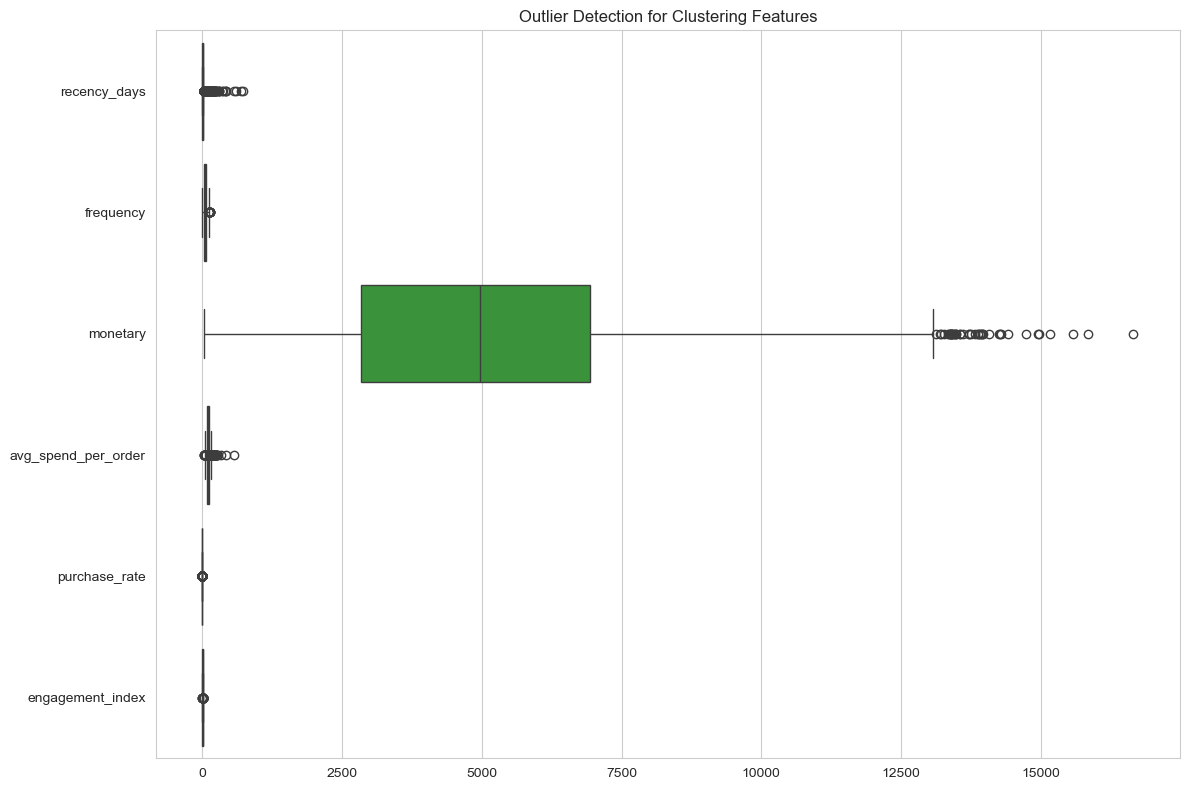

In [6]:
"""
Outlier Detection via Boxplots
"""

plt.figure(figsize=(12,8))

sns.boxplot(
    data=clustering_features,
    orient="h"
)

plt.title("Outlier Detection for Clustering Features")

save_plot("clustering_feature_outliers.png")

In [7]:
"""
Feature Scaling
"""

scaler = StandardScaler()

X_scaled = scaler.fit_transform(clustering_features)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features.columns
)

X_scaled.head()

,recency_days,frequency,monetary,avg_spend_per_order,purchase_rate,engagement_index
0,-0.141651,-0.102862,-0.216260,-0.322372,-0.588722,-0.046846
1,-0.028118,0.726382,0.106517,-1.083248,-0.125530,0.929672
2,-0.255183,-0.379277,-0.422286,-0.200112,-0.739361,0.800889
3,-0.330871,2.700773,2.219785,-0.374280,0.974152,0.881474
4,-0.368716,-1.287496,-1.044008,1.318239,-1.242555,0.271982


In [8]:
"""
Apply PCA
"""

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

pca_variance = pca.explained_variance_ratio_

pca_variance

array([0.48468521, 0.18171299, 0.15720869, 0.13469057, 0.03876752,
       0.00293502])

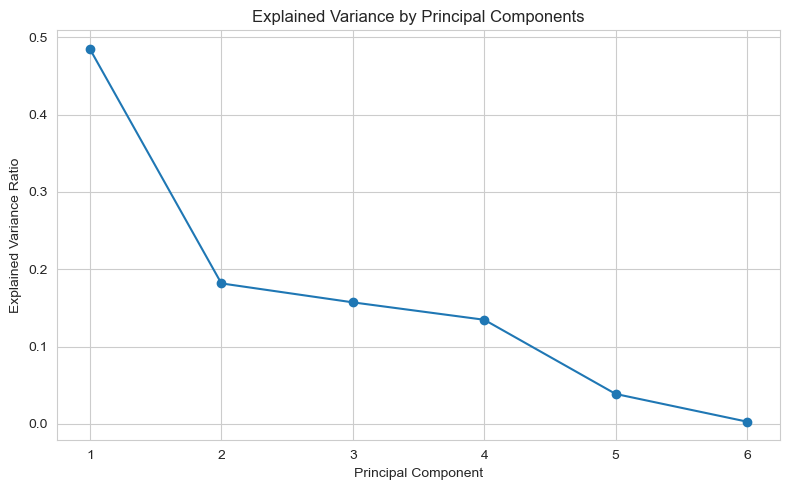

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_variance)+1),
    pca_variance,
    marker="o"
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

save_plot("pca_explained_variance.png")

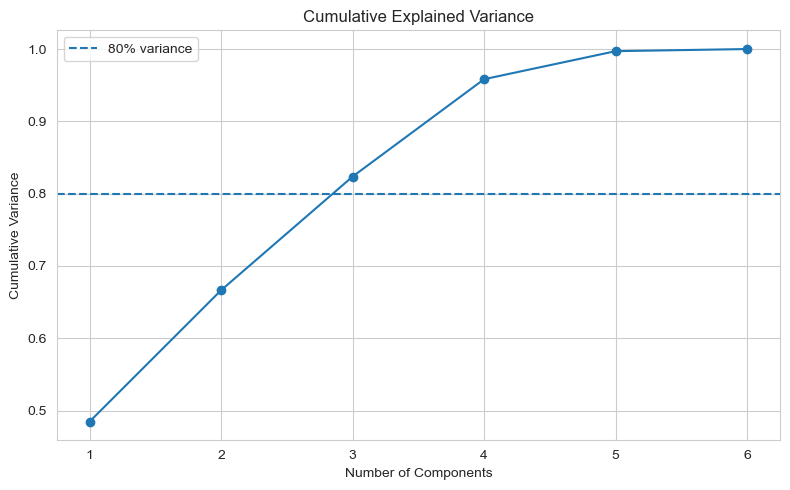

In [10]:
cumulative_variance = np.cumsum(pca_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.8,
    linestyle="--",
    label="80% variance"
)

plt.legend()

plt.title("Cumulative Explained Variance")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

save_plot("pca_cumulative_variance.png")

## Determining the Optimal Number of Clusters

Choosing the appropriate number of clusters is a critical step in clustering analysis.

If the number of clusters is too small, different customer segments may be merged together.

If it is too large, clusters may become fragmented and difficult to interpret.

To determine the optimal number of clusters, we use two complementary techniques:

### Elbow Method

Evaluates how the within-cluster variance decreases as the number of clusters increases.

### Silhouette Score

Measures how well-separated the clusters are.

Higher silhouette scores indicate better clustering structure.

In [11]:
"""
Compute Elbow and Silhouette Scores
"""

inertia_values = []
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

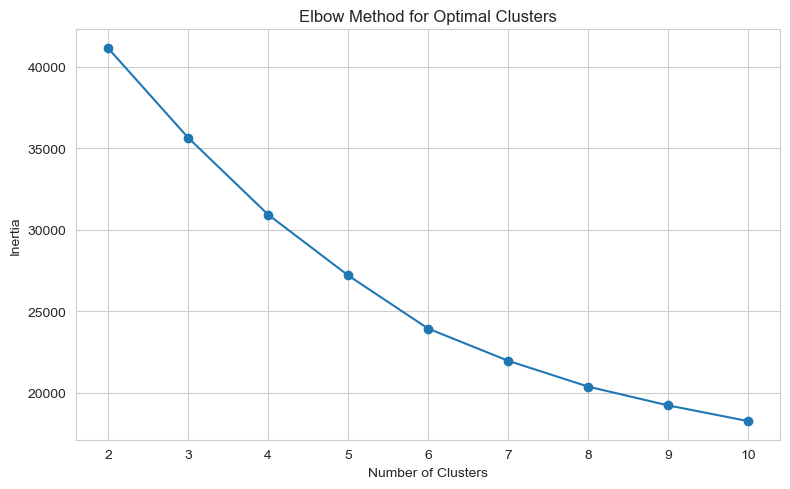

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

save_plot("kmeans_elbow_method.png")

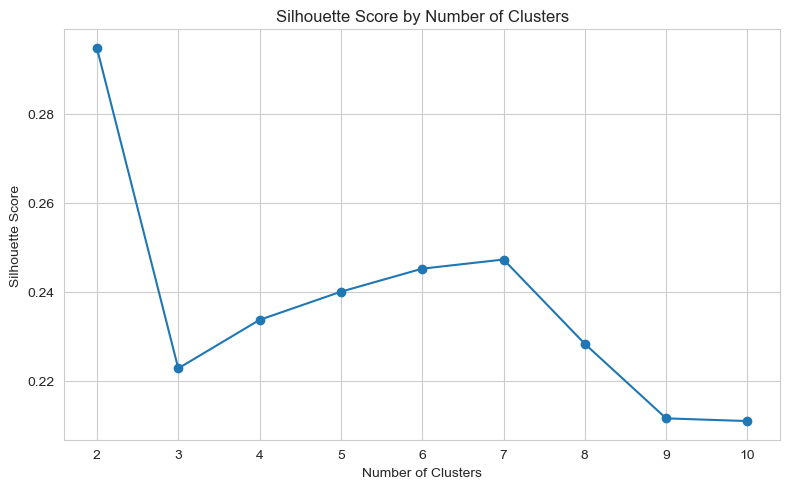

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

save_plot("kmeans_silhouette_scores.png")

In [14]:
"""
Cluster Evaluation Summary
"""

cluster_eval = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertia_values,
    "silhouette_score": silhouette_scores
})

cluster_eval

,k,inertia,silhouette_score
0,2,41143.286500,0.294788
1,3,35648.537138,0.222735
2,4,30926.993572,0.233641
3,5,27194.790978,0.239981
4,6,23928.785443,0.245161
5,7,21952.980019,0.247223
6,8,20366.440983,0.228248
7,9,19212.862116,0.211491
8,10,18248.845833,0.210880


In [15]:
cluster_eval.sort_values(
    "silhouette_score",
    ascending=False
)

,k,inertia,silhouette_score
0,2,41143.286500,0.294788
5,7,21952.980019,0.247223
4,6,23928.785443,0.245161
3,5,27194.790978,0.239981
2,4,30926.993572,0.233641
6,8,20366.440983,0.228248
1,3,35648.537138,0.222735
7,9,19212.862116,0.211491
8,10,18248.845833,0.210880


## KMeans Clustering

After evaluating multiple cluster configurations using the Elbow Method and Silhouette Score, we select the optimal number of clusters.

KMeans is a centroid-based clustering algorithm that partitions observations into groups based on distance to cluster centroids.

The algorithm iteratively performs two steps:

1. Assign each observation to the nearest centroid.
2. Update centroid positions based on the assigned observations.

The objective is to minimize the within-cluster variance.

Once the model is fitted, each customer will be assigned a cluster label.

In [16]:
"""
Train Final KMeans Model
"""

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [17]:
"""
Attach Cluster Labels to Dataset
"""

customer_features["cluster"] = cluster_labels

customer_features.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase,customer_tenure_days_x,engagement_index,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order,customer_tenure_days_y,purchase_rate,cluster
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0,730,4.461865,7.0,47.0,4547.73,2.0,3.0,3.0,233.0,At Risk,96.760213,730.0,0.064295,1
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0,728,5.731441,10.0,68.0,5440.13,2.0,4.0,3.0,243.0,At Risk,80.001912,728.0,0.093278,1
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0,728,5.564010,4.0,40.0,3978.12,3.0,2.0,2.0,322.0,At Risk,99.453000,728.0,0.054870,0
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0,727,5.668780,2.0,118.0,11282.80,4.0,5.0,5.0,455.0,At Risk,95.616949,727.0,0.162088,2
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0,726,4.876375,1.0,17.0,2259.21,5.0,1.0,1.0,511.0,At Risk,132.894706,726.0,0.023384,0


In [18]:
"""
Cluster Size Analysis
"""

cluster_sizes = customer_features["cluster"].value_counts()

cluster_sizes

cluster
1    4247
0    3591
2    1908
3     254
Name: count, dtype: int64

In [19]:
cluster_sizes.sort_index()

cluster
0    3591
1    4247
2    1908
3     254
Name: count, dtype: int64

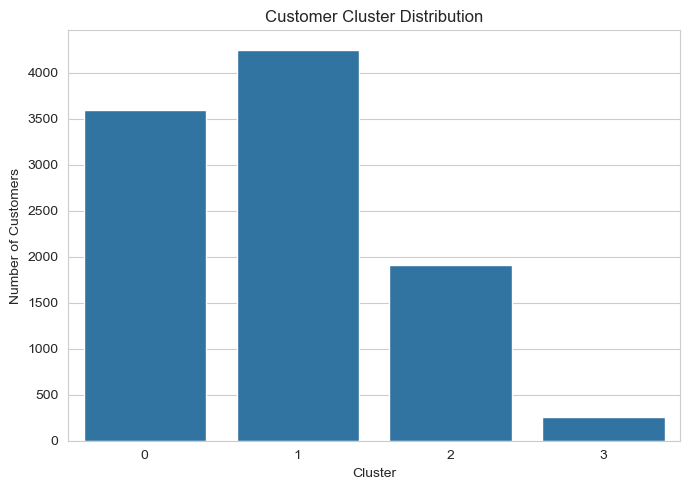

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customer_features,
    x="cluster",
    order=sorted(customer_features["cluster"].unique())
)

plt.title("Customer Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

save_plot("customer_cluster_distribution.png")

## Cluster Visualization using PCA

Customer datasets often contain multiple features, making direct visualization difficult.

Principal Component Analysis (PCA) reduces the dimensionality of the data while preserving as much variance as possible.

By projecting the data onto the first two principal components, we can visualize cluster structure in a two-dimensional space.

This visualization helps assess:

- cluster separation
- overlap between clusters
- general clustering quality

In [21]:
"""
Compute PCA Projection
"""

pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = cluster_labels

pca_df.head()

,PC1,PC2,cluster
0,-0.470350,-0.345575,1
1,0.494439,-1.206999,1
2,-0.654033,-0.574044,0
3,3.470324,-0.300195,2
4,-1.743803,0.743434,0


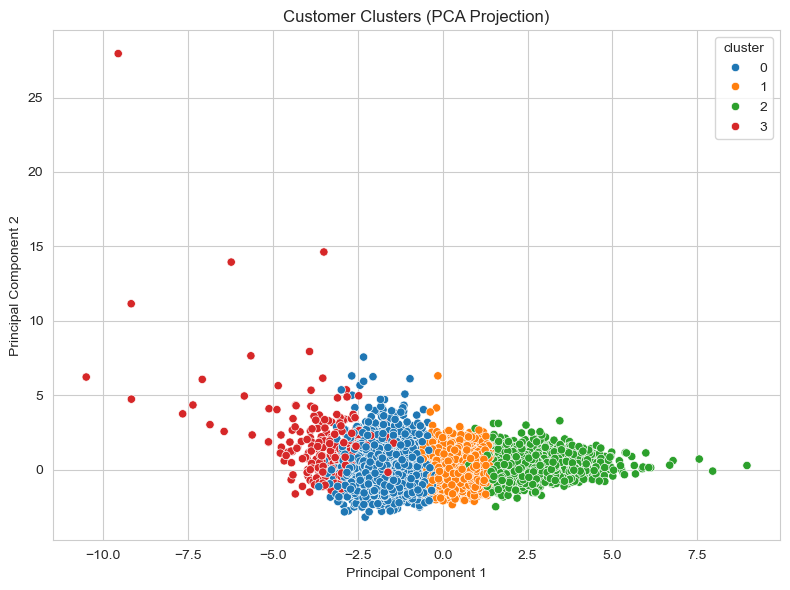

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10"
)

plt.title("Customer Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

save_plot("customer_clusters_pca.png")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


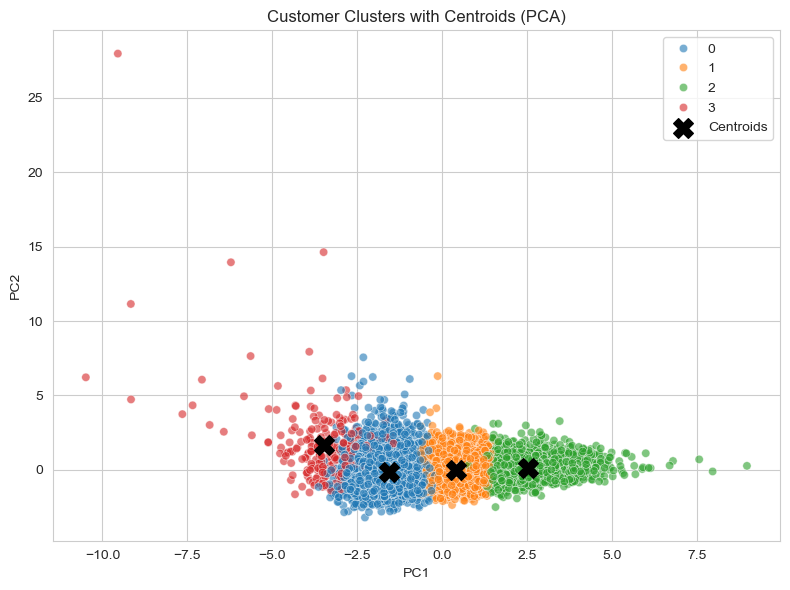

In [23]:
centroids = pca_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroids"
)

plt.legend()

plt.title("Customer Clusters with Centroids (PCA)")

save_plot("customer_clusters_centroids_pca.png")

## Cluster Profiling

After clustering customers, the next step is to analyze the characteristics of each cluster.

Cluster profiling helps identify behavioral patterns and understand how different groups of customers behave.

We examine the average values of key features within each cluster, including:

- recency
- purchase frequency
- total spending
- engagement levels
- customer tenure

This analysis allows us to interpret clusters and translate them into meaningful customer segments.

In [24]:
"""
Compute Cluster Feature Means (Robust Version)
"""

profiling_features = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_spend_per_order",
    "purchase_rate",
    "engagement_index",
    "customer_tenure_days"
]

# Keep only features present in dataset
available_features = [
    col for col in profiling_features
    if col in customer_features.columns
]

print("Profiling using features:", available_features)

cluster_profile = customer_features.groupby("cluster")[
    available_features
].mean()

cluster_profile

Profiling using features: ['recency_days', 'frequency', 'monetary', 'avg_spend_per_order', 'purchase_rate', 'engagement_index']


,recency_days,frequency,monetary,avg_spend_per_order,purchase_rate,engagement_index
cluster,,,,,,
0,13.367307,24.789474,2520.515698,102.589759,0.048810,4.437033
1,4.849470,56.222379,5772.850905,103.386631,0.110306,4.399228
2,3.100105,86.394130,9188.172290,106.932908,0.189043,5.061578
3,129.602362,13.488189,1411.325354,106.680291,0.027263,3.753161


In [25]:
cluster_profile_rounded = cluster_profile.round(2)

cluster_profile_rounded

,recency_days,frequency,monetary,avg_spend_per_order,purchase_rate,engagement_index
cluster,,,,,,
0,13.37,24.79,2520.52,102.59,0.05,4.44
1,4.85,56.22,5772.85,103.39,0.11,4.40
2,3.10,86.39,9188.17,106.93,0.19,5.06
3,129.60,13.49,1411.33,106.68,0.03,3.75


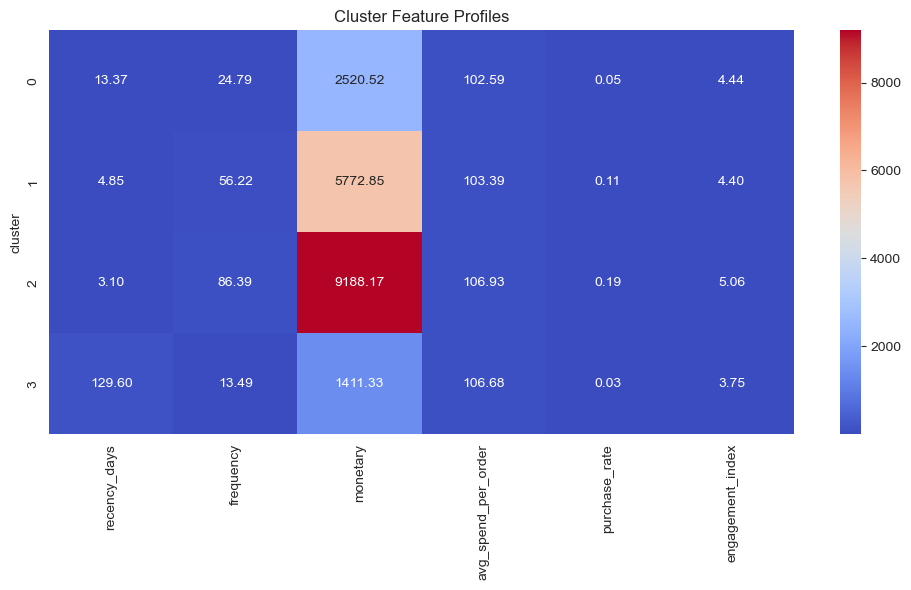

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster Feature Profiles")

save_plot("cluster_feature_profiles_heatmap.png")

In [27]:
"""
Revenue Contribution by Cluster
"""

revenue_by_cluster = customer_features.groupby("cluster")[
    "monetary"
].sum()

revenue_by_cluster

cluster
0     9051171.87
1    24505752.09
2    17531032.73
3      358476.64
Name: monetary, dtype: float64

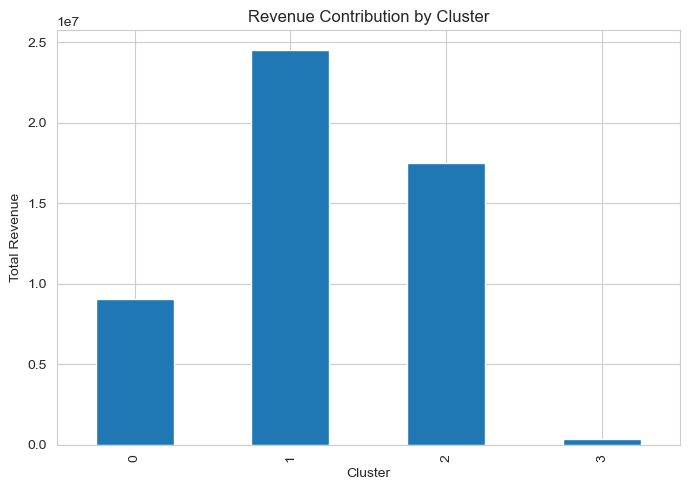

In [28]:
plt.figure(figsize=(7,5))

revenue_by_cluster.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Revenue")

save_plot("revenue_by_cluster.png")

## Business Interpretation of Customer Segments

Clustering algorithms produce numerical cluster labels that need to be interpreted from a business perspective.

By analyzing the behavioral patterns and feature profiles of each cluster, we can assign meaningful customer segment names.

Typical e-commerce customer segments include:

High Value Customers

Customers with high spending and frequent purchases.

Frequent Buyers

Customers who purchase often but with moderate spending.

At Risk Customers

Customers who were previously active but have not purchased recently.

Low Engagement Customers

Customers with low purchasing activity and limited platform interaction.

These segments allow businesses to design targeted marketing strategies.

In [29]:
"""
Assign Business Segment Names
"""

segment_map = {
    0: "High Value Customers",
    1: "Frequent Buyers",
    2: "At Risk Customers",
    3: "Low Engagement Customers"
}

customer_features["segment"] = customer_features["cluster"].map(segment_map)

customer_features.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase,customer_tenure_days_x,engagement_index,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order,customer_tenure_days_y,purchase_rate,cluster,segment
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0,730,4.461865,7.0,47.0,4547.73,2.0,3.0,3.0,233.0,At Risk,96.760213,730.0,0.064295,1,Frequent Buyers
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0,728,5.731441,10.0,68.0,5440.13,2.0,4.0,3.0,243.0,At Risk,80.001912,728.0,0.093278,1,Frequent Buyers
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0,728,5.564010,4.0,40.0,3978.12,3.0,2.0,2.0,322.0,At Risk,99.453000,728.0,0.054870,0,High Value Customers
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0,727,5.668780,2.0,118.0,11282.80,4.0,5.0,5.0,455.0,At Risk,95.616949,727.0,0.162088,2,At Risk Customers
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0,726,4.876375,1.0,17.0,2259.21,5.0,1.0,1.0,511.0,At Risk,132.894706,726.0,0.023384,0,High Value Customers


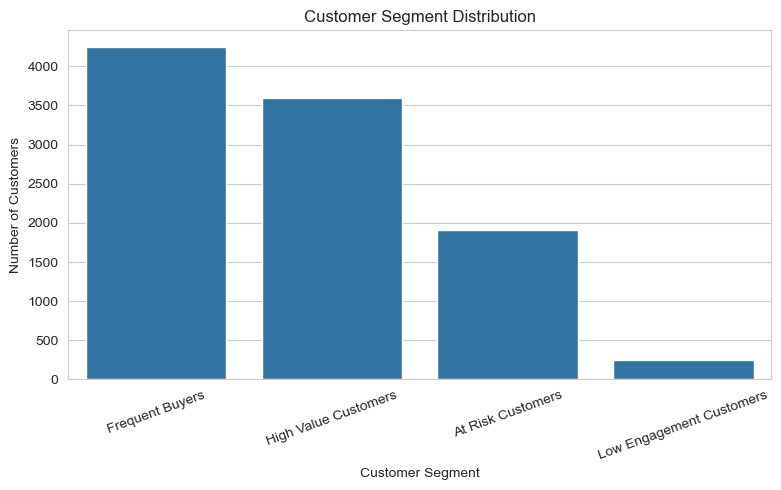

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_features,
    x="segment",
    order=customer_features["segment"].value_counts().index
)

plt.xticks(rotation=20)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

save_plot("customer_segment_distribution.png")

## Marketing Strategies by Customer Segment

The identified customer segments enable more personalized marketing strategies.

### High Value Customers

These customers generate a large portion of revenue.

Recommended strategies:

- VIP loyalty programs
- early access to promotions
- personalized product recommendations

---

### Frequent Buyers

Customers who purchase regularly but may have moderate spending.

Recommended strategies:

- cross-selling campaigns
- bundle offers
- subscription models

---

### At Risk Customers

Previously active customers who have not purchased recently.

Recommended strategies:

- reactivation campaigns
- personalized discounts
- reminder emails

---

### Low Engagement Customers

Customers with low activity and limited interaction with the platform.

Recommended strategies:

- onboarding campaigns
- introductory discounts
- product discovery campaigns